In [3]:
# Daily Household Transactions Analysis

# Objective:
#To analyze daily household financial transactions and identify spending patterns,income vs expense behavior, and monthly trends using Python.


In [4]:
## Step 1: Import Required Libraries

# We import pandas for data handling, matplotlib and seaborn for visualization.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [7]:
## Step 2: Load the Dataset

# The dataset contains daily household transactions including income and expenses.


In [9]:
df = pd.read_csv("Daily Household Transactions.csv")
df.head()


,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [10]:
## Step 3: Understand Dataset Structure

# We check the number of rows, columns, data types, and missing values.


In [11]:
df.shape


(2461, 8)

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


In [13]:
df.isnull().sum()


,0
Date,0
Mode,0
Category,0
Subcategory,635
Note,521
Amount,0
Income/Expense,0
Currency,0


In [14]:
df["Subcategory"] = df["Subcategory"].fillna("Unknown")
df["Note"] = df["Note"].fillna("Unknown")


In [15]:
df.isnull().sum()

,0
Date,0
Mode,0
Category,0
Subcategory,0
Note,0
Amount,0
Income/Expense,0
Currency,0


In [16]:
## Step 5: Income vs Expense Analysis

# We analyze how many transactions are income and how many are expenses,and compare the total amount.


In [18]:
df["Income/Expense"].value_counts()


,count
Income/Expense,
Expense,2176
Transfer-Out,160
Income,125


In [20]:
df.groupby("Income/Expense")["Amount"].sum()


,Amount
Income/Expense,
Expense,1957390.53
Income,3042397.35
Transfer-Out,1770780.90


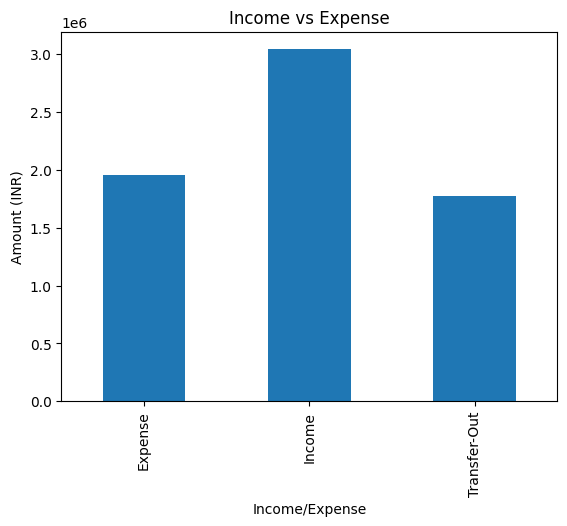

In [22]:
df.groupby("Income/Expense")["Amount"].sum().plot(kind="bar")
plt.title("Income vs Expense")
plt.ylabel("Amount (INR)")
plt.show()


In [23]:
## Step 6: Category-wise Expense Analysis

# We identify the top categories where most money is spent.


In [25]:
top_categories = (
    df[df["Income/Expense"] == "Expense"]
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_categories


,Amount
Category,
Money transfer,606528.90
Investment,271858.00
Transportation,169053.78
Household,161645.58
subscription,114587.91


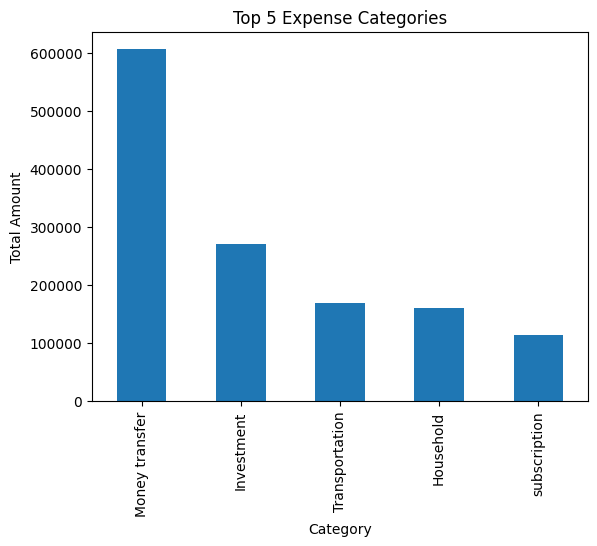

In [27]:
top_categories.plot(kind="bar")
plt.title("Top 5 Expense Categories")
plt.ylabel("Total Amount")
plt.xlabel("Category")
plt.show()


In [28]:
## Step 7: Payment Mode Analysis

# This shows which payment methods are most commonly used.


In [30]:
df["Mode"].value_counts().head(5)


,count
Mode,
Saving Bank account 1,1223
Cash,1046
Credit Card,162
Equity Mutual Fund B,11
Share Market Trading,5


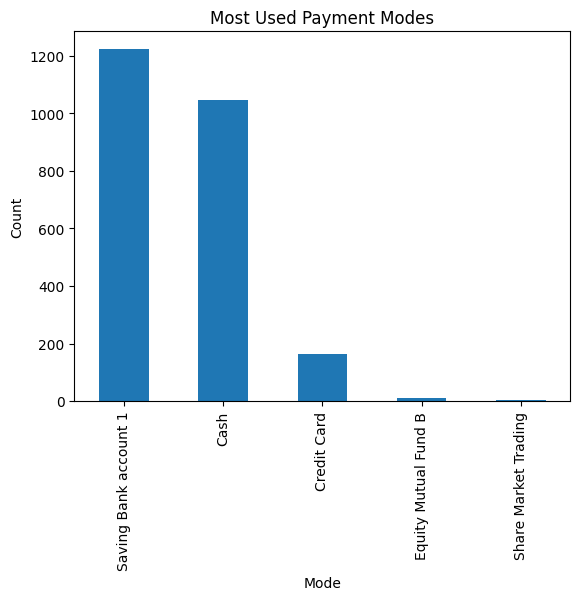

In [31]:
df["Mode"].value_counts().head(5).plot(kind="bar")
plt.title("Most Used Payment Modes")
plt.ylabel("Count")
plt.show()


In [32]:
## Step 8: Time Series Analysis

# We analyze monthly spending trends to observe changes over time.


In [33]:
df["Month"] = df["Date"].dt.to_period("M")


AttributeError: Can only use .dt accessor with datetimelike values

In [34]:
df.dtypes



,0
Date,object
Mode,object
Category,object
Subcategory,object
Note,object
Amount,float64
Income/Expense,object
Currency,object


In [35]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")


In [36]:
df = df.dropna(subset=["Date"])


In [37]:
df[["Date", "Month"]].head()


KeyError: "['Month'] not in index"

In [38]:
df["Month"] = df["Date"].dt.to_period("M")


In [39]:
df[["Date", "Month"]].head()


,Date,Month
0,2018-09-20 12:04:08,2018-09
1,2018-09-20 12:03:15,2018-09
3,2018-09-17 23:41:17,2018-09
4,2018-09-16 17:15:08,2018-09
5,2018-09-15 06:34:17,2018-09


In [40]:
"Month" in df.columns


True

In [41]:
df["Month"] = df["Date"].dt.to_period("M")


In [42]:
monthly_expense = (
    df[df["Income/Expense"] == "Expense"]
    .groupby("Month")["Amount"]
    .sum()
)

monthly_expense


,Amount
Month,
2015-01,4434.00
2015-02,6710.00
2015-03,6509.80
2015-04,3791.00
2015-05,21076.00
2015-06,1198.00
2015-07,2798.00
2015-08,15507.00
2015-09,3198.00


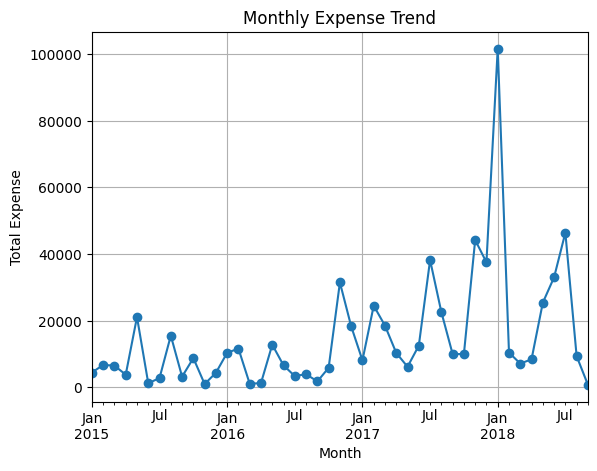

In [43]:
monthly_expense.plot(kind="line", marker="o")
plt.title("Monthly Expense Trend")
plt.ylabel("Total Expense")
plt.xlabel("Month")
plt.grid(True)
plt.show()


In [44]:
## Step 9: Monthly Income vs Expense Comparison


In [45]:
monthly_summary = (
    df.groupby(["Month", "Income/Expense"])["Amount"]
    .sum()
    .unstack()
)

monthly_summary


Income/Expense,Expense,Income,Transfer-Out
Month,,,
2015-01,4434.00,NaN,NaN
2015-02,6710.00,49806.00,NaN
2015-03,6509.80,70806.00,NaN
2015-04,3791.00,49306.00,NaN
2015-05,21076.00,47859.00,NaN
2015-06,1198.00,47859.00,NaN
2015-07,2798.00,47859.00,NaN
2015-08,15507.00,49806.00,NaN
2015-09,3198.00,49806.00,NaN


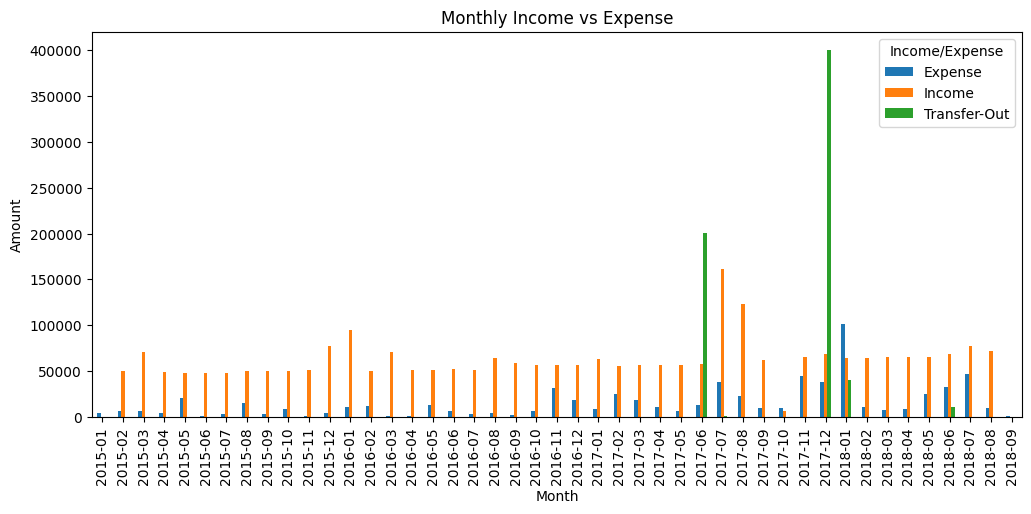

In [46]:
monthly_summary.plot(kind="bar", figsize=(12,5))
plt.title("Monthly Income vs Expense")
plt.ylabel("Amount")
plt.xlabel("Month")
plt.show()


In [49]:
## Conclusion

# Expenses are more frequent than income transactions.
# Food and Transportation are the highest expense categories.
# Cash and bank accounts are the most used payment modes.
# Monthly expenses show fluctuations indicating seasonal behavior.

# This analysis helps understand personal spending habits and supportsbetter budgeting and financial planning.
